In [1]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from pathlib import Path

os.chdir(r'E:\Job\Project\Clinical-trial-enrollment')
conn  = sqlite3.connect('clinical_trial.db')
Path('outputs').mkdir(exist_ok=True)

df    = pd.read_sql('SELECT * FROM trials', conn)
df_km = df[df['duration_months'] > 0].copy()
df_km['event'] = 1

print(f'Trials for KM analysis: {len(df_km):,}')
print(df_km['phase'].value_counts())

Trials for KM analysis: 1,890
phase
Phase 3      882
Phase 2      733
Phase 1/2    145
Phase 2/3    130
Name: count, dtype: int64


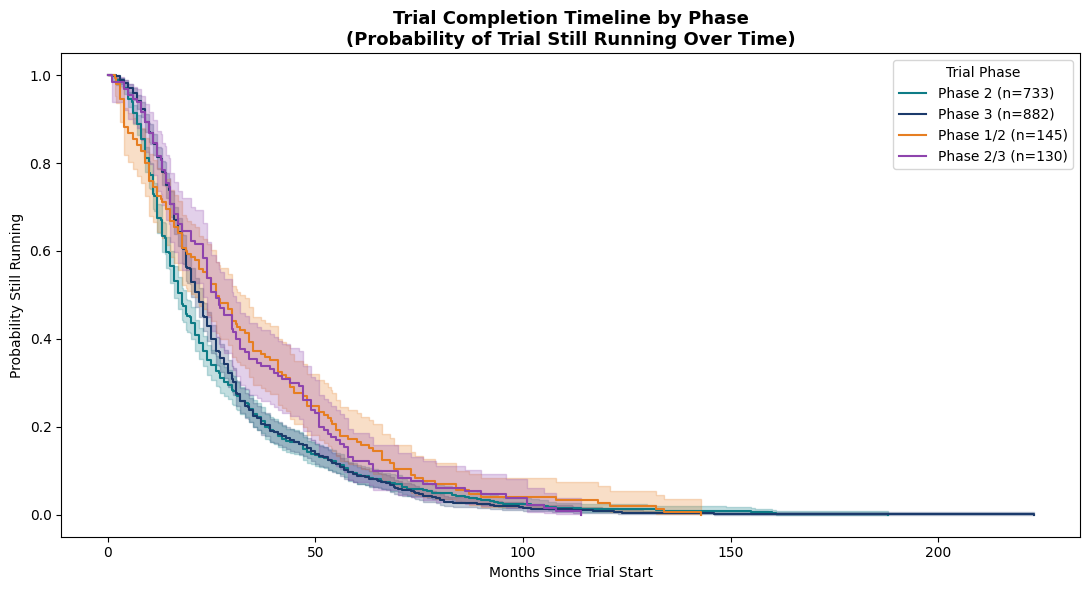


Median completion time by phase:
  Phase 2: 18 months
  Phase 3: 22 months
  Phase 1/2: 26 months
  Phase 2/3: 26 months


In [2]:
# KM Curve — Trial Completion by Phase
fig, ax = plt.subplots(figsize=(11, 6))
colors  = {
    'Phase 2':   '#0E7C86',
    'Phase 3':   '#1B3A6B',
    'Phase 1/2': '#E67E22',
    'Phase 2/3': '#8E44AD'
}
kmf = KaplanMeierFitter()

for phase, color in colors.items():
    mask = df_km['phase'] == phase
    if mask.sum() < 10:
        continue
    kmf.fit(df_km[mask]['duration_months'],
            df_km[mask]['event'],
            label=f'{phase} (n={mask.sum()})')
    kmf.plot_survival_function(ax=ax, ci_show=True, color=color)

ax.set_title('Trial Completion Timeline by Phase\n'
             '(Probability of Trial Still Running Over Time)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Months Since Trial Start')
ax.set_ylabel('Probability Still Running')
ax.legend(title='Trial Phase')
plt.tight_layout()
plt.savefig('outputs/06_km_by_phase.png', dpi=150)
plt.show()

# Print median completion time
print('\nMedian completion time by phase:')
for phase in colors:
    mask = df_km['phase'] == phase
    if mask.sum() < 10: continue
    kmf.fit(df_km[mask]['duration_months'], df_km[mask]['event'])
    print(f'  {phase}: {kmf.median_survival_time_:.0f} months')